# ⚡ Practical 1 — Your First Energy Data Challenge
## Python + AI for exploring a renewable electricity system

This practical turns ideas from the first lecture into a small computational experiment.

We will work with:

- **power and energy**;
- electricity demand;
- wind and solar generation;
- renewable intermittency;
- energy storage;
- grid integration;
- engineering trade-offs;
- LLMs as an assistant that must be **checked**.

You do **not** need previous programming experience.

### Main question

> **Can we supply one day of electricity demand using wind, solar and a battery?**

### What you should be able to do by the end

You should be able to:

1. read and modify simple Python code;
2. use variables, lists/arrays, arithmetic, `if`, and `for`;
3. distinguish MW from MWh;
4. inspect an hourly energy profile;
5. identify renewable surplus and deficit periods;
6. explore the effect of a battery;
7. ask an LLM to explain, debug and suggest;
8. verify an LLM recommendation using data.

> The data in this practical are **synthetic teaching data**, not actual Estonian grid measurements.

# 👥 How we will work today

This is not a “follow the code silently” practical.

During the session you will repeatedly use this cycle:

### 👀 PREDICT → 👥 DISCUSS → ▶️ TEST → 🤖 ASK AI → 🔎 VERIFY

Some tasks are individual, some are pair discussions, and the final challenge is a small team task.

When you see **DO NOT RUN YET**, first make a prediction.

# 1. Warm-up — Energy or Power?

Before coding, discuss these statements with the person next to you.

1. A heater rated at **2 kW** describes energy or power?
2. A heater uses **6 kWh** during an evening. What does 6 kWh describe?
3. A 2 kW heater runs for 3 hours. How much energy does it use?
4. A wind farm has a rated capacity of 100 MW. Does it always generate 100 MW?

Now use the quiz below.

In [2]:
# @title
import ipywidgets as widgets
from IPython.display import display, clear_output

quiz = [
    {
        "question": "A heater is rated at 2 kW. What does 2 kW describe?",
        "options": ["Energy", "Power", "Voltage"],
        "answer": "Power",
        "explanation": "kW is a unit of power: the rate at which energy is used."
    },
    {
        "question": "A heater uses 6 kWh during an evening. What does 6 kWh describe?",
        "options": ["Energy", "Power", "Current"],
        "answer": "Energy",
        "explanation": "kWh is a unit of energy."
    },
    {
        "question": "A 2 kW heater runs for 3 hours. How much energy does it use?",
        "options": ["0.67 kWh", "5 kWh", "6 kWh"],
        "answer": "6 kWh",
        "explanation": "Energy = Power × Time = 2 kW × 3 h = 6 kWh."
    },
    {
        "question": "If a wind farm has a rated capacity of 100 MW, does it always generate 100 MW?",
        "options": ["Yes", "No"],
        "answer": "No",
        "explanation": "Rated capacity is not constant output. Wind generation depends on weather."
    }
]

q_index = widgets.IntSlider(value=0, min=0, max=len(quiz)-1, step=1, description="Question:")
choice = widgets.RadioButtons()
button = widgets.Button(description="Check answer")
output = widgets.Output()

def load_question(change=None):
    q = quiz[q_index.value]
    choice.options = q["options"]
    choice.value = q["options"][0]
    with output:
        clear_output()
        print(q["question"])

def check_answer(_):
    q = quiz[q_index.value]
    with output:
        clear_output()
        print(q["question"])
        print("✅ Correct" if choice.value == q["answer"] else "❌ Not quite")
        print(q["explanation"])

q_index.observe(load_question, names="value")
button.on_click(check_answer)

load_question()
display(q_index, output, choice, button)

IntSlider(value=0, description='Question:', max=3)

Output()

RadioButtons(options=('Energy', 'Power', 'Voltage'), value='Energy')

Button(description='Check answer', style=ButtonStyle())

## 🤖 AI check

Choose **one** statement from the quiz and ask an LLM:

> Explain whether this statement is correct. Use the terms **energy** and **power** precisely. Keep the answer short.

Then compare the AI explanation with your own understanding.

**Discuss with your partner:**

- Did it use MW / kW and MWh / kWh correctly?
- Was anything vague or misleading?

# 2. Python Survival Kit

We start with Python as a calculator.

A heater has a power of 2 kW and operates for 3 hours.

$ E = P \times t $

Run the cell.

In [3]:
power_kw = 2
hours_used = 3

energy_kwh = power_kw * hours_used

print("Energy used:", energy_kwh, "kWh")

Energy used: 6 kWh


### ✏️ Your turn

A device uses **1.5 kW** for **4 hours**.

Create:

- `device_power_kw`
- `device_hours`
- `device_energy_kwh`

Then print the result.

In [4]:
# YOUR CODE HERE

# 3. Meet the 24-hour energy system

We now move from one calculation to a small dataset.

There is one value per hour:

- `demand` — electricity demand [MW];
- `solar_cf` — fraction of installed solar capacity producing;
- `wind_cf` — fraction of installed wind capacity producing.

The profiles are provided to you. Their generation procedure is not part of today's task.

In [5]:
# @title
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)

demand = np.array([850, 840, 820, 810, 820, 900, 950, 1030, 1120, 1170, 1100, 1140, 1030, 1130, 1150, 1220, 1390, 1450, 1490, 1420, 1320, 1180, 1000, 910], dtype=float)

solar_cf = np.array([0, 0, 0, 0, 0, 0, 0.02, 0.14, 0.3, 0.47, 0.63, 0.75, 0.81, 0.81, 0.75, 0.63, 0.47, 0.3, 0.14, 0.02, 0, 0, 0, 0], dtype=float)

wind_cf = np.array([0.55, 0.52, 0.41, 0.47, 0.37, 0.29, 0.24, 0.27, 0.34, 0.32, 0.31, 0.32, 0.32, 0.34, 0.32, 0.37, 0.41, 0.35, 0.38, 0.42, 0.46, 0.44, 0.41, 0.39], dtype=float)

print("Hours:", len(hours))
print("Demand values:", len(demand))

Hours: 24
Demand values: 24


## 👀 PREDICT — do not calculate yet

Look only at the demand values.

Discuss in pairs:

1. At roughly what time do you expect peak demand?
2. Why might electricity demand be lower at night?
3. Would one daily average be enough to describe this system?

Now plot the profile.

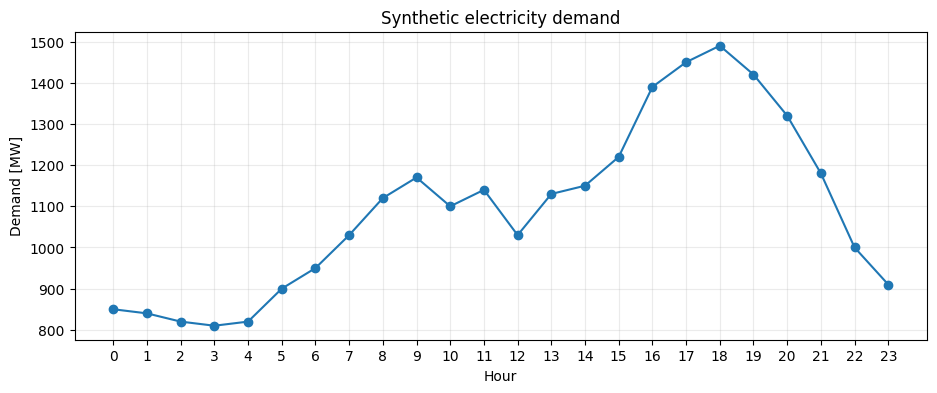

In [6]:
plt.figure(figsize=(11, 4))
plt.plot(hours, demand, marker="o")
plt.xlabel("Hour")
plt.ylabel("Demand [MW]")
plt.title("Synthetic electricity demand")
plt.xticks(hours)
plt.grid(alpha=0.25)
plt.show()

### ✏️ Exercise — simple statistics

Find:

1. total daily electricity demand in MWh;
2. peak demand in MW;
3. the hour of peak demand.

Useful tools:

```python
demand.sum()
demand.max()
np.argmax(demand)
```

Because each value represents one hour, summing hourly MW values gives MWh in this simplified dataset.

In [26]:
# YOUR CODE HERE


# 4. Add solar and wind

Let us install:

- 1000 MW of solar;
- 1500 MW of wind.

Actual hourly generation is:

> installed capacity × capacity factor

In [8]:
solar_capacity_mw = 1000
wind_capacity_mw = 1500

solar = solar_capacity_mw * solar_cf
wind = wind_capacity_mw * wind_cf
renewable_generation = solar + wind

## 👀 PREDICT — DO NOT RUN THE NEXT PLOT YET



**What do you expect over the full day?**

A. Solar + wind will produce much less energy than demand  
B. Solar + wind will produce roughly the same total energy as demand  
C. Solar + wind will produce more total energy than demand

Also predict:

- When will solar be most useful?
- When will the largest renewable deficit occur?

Only then run the plot.

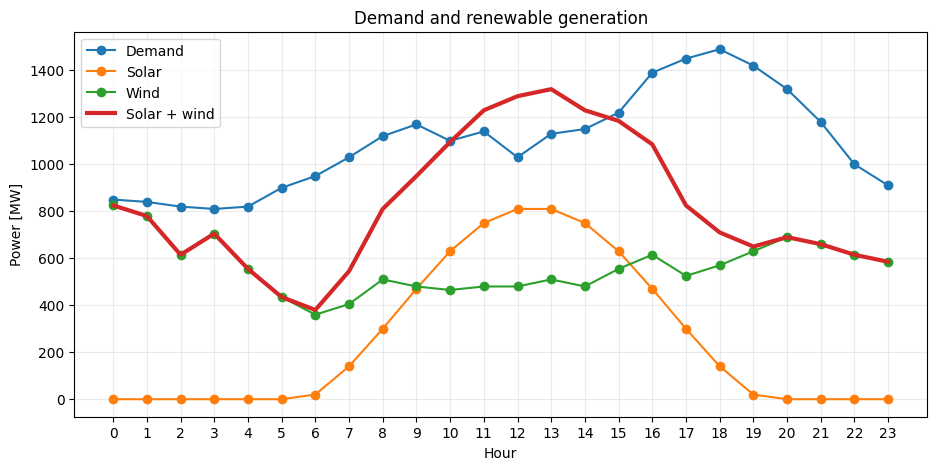

In [9]:
plt.figure(figsize=(11, 5))
plt.plot(hours, demand, marker="o", label="Demand")
plt.plot(hours, solar, marker="o", label="Solar")
plt.plot(hours, wind, marker="o", label="Wind")
plt.plot(hours, renewable_generation, linewidth=3, label="Solar + wind")
plt.xlabel("Hour")
plt.ylabel("Power [MW]")
plt.title("Demand and renewable generation")
plt.xticks(hours)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Calculate the daily totals

Run the next cell.

In [10]:
total_demand_mwh = demand.sum()
total_renewable_mwh = renewable_generation.sum()

generation_to_demand_ratio = 100 * total_renewable_mwh / total_demand_mwh

print("Daily demand:", round(total_demand_mwh, 1), "MWh")
print("Daily solar + wind generation:", round(total_renewable_mwh, 1), "MWh")
print("Generation / demand:", round(generation_to_demand_ratio, 1), "%")

Daily demand: 26240.0 MWh
Daily solar + wind generation: 19770.0 MWh
Generation / demand: 75.3 %


# 🗣️ Convince your neighbour

Suppose total solar + wind generation over a day is greater than total electricity demand.

Does that prove we can operate the system without backup generation?

Choose:

- **A — Yes**
- **B — No**
- **C — Not enough information**

First choose individually.

Then find somebody with a different answer and try to convince each other.

After the discussion, you may change your answer.

# 5. Hourly balance — surplus or deficit

A daily total can hide what happens hour by hour.

For every hour:

$
\mathrm{balance} = \mathrm{renewable\ generation} - \mathrm{demand}
$

- positive → surplus;
- negative → deficit.

In [11]:
for hour in range(24):
    balance = renewable_generation[hour] - demand[hour]

    if balance >= 0:
        print(hour, "SURPLUS", round(balance, 1), "MW")
    else:
        print(hour, "DEFICIT", round(balance, 1), "MW")

0 DEFICIT -25.0 MW
1 DEFICIT -60.0 MW
2 DEFICIT -205.0 MW
3 DEFICIT -105.0 MW
4 DEFICIT -265.0 MW
5 DEFICIT -465.0 MW
6 DEFICIT -570.0 MW
7 DEFICIT -485.0 MW
8 DEFICIT -310.0 MW
9 DEFICIT -220.0 MW
10 DEFICIT -5.0 MW
11 SURPLUS 90.0 MW
12 SURPLUS 260.0 MW
13 SURPLUS 190.0 MW
14 SURPLUS 80.0 MW
15 DEFICIT -35.0 MW
16 DEFICIT -305.0 MW
17 DEFICIT -625.0 MW
18 DEFICIT -780.0 MW
19 DEFICIT -770.0 MW
20 DEFICIT -630.0 MW
21 DEFICIT -520.0 MW
22 DEFICIT -385.0 MW
23 DEFICIT -325.0 MW


### ✏️ Exercise — count deficit hours

Complete the code.

```python
deficit_hours = 0

for hour in range(24):
    ...
```

In [12]:
# YOUR CODE HERE

## 👥 Pair discussion

Compare the deficit hours with the plot.

Discuss:

- Are the deficit hours consecutive or scattered?
- Is the problem “not enough renewable energy” or “renewable energy at the wrong time”?
- What could we do with renewable surplus?

# 6. 🔧 LLM Debug Challenge

The following code is **logically wrong** for our purpose.

We want **one daily percentage**, but this expression produces something else.

Run it and inspect the output.

In [13]:
broken_share = renewable_generation / demand.sum() * 100
print(broken_share)

[3.14405488 2.97256098 2.34375    2.6867378  2.11509146 1.65777439
 1.44817073 2.07698171 3.08689024 3.62042683 4.17301829 4.6875
 4.91615854 5.0304878  4.6875     4.5160061  4.13490854 3.14405488
 2.70579268 2.47713415 2.62957317 2.5152439  2.34375    2.22942073]


Ask an LLM:

> I want one value for total daily renewable generation divided by total daily demand.  
> My code is:
>
> `renewable_generation / demand.sum() * 100`
>
> Explain the logical error before giving corrected Python code.

Then:

1. read the explanation;
2. decide whether it makes sense;
3. write the corrected expression below;
4. compare it with the value calculated earlier.

**Do not simply paste the AI answer without understanding it.**

In [14]:
# YOUR CORRECTED CODE HERE

# 7. Add battery storage 🔋

Renewable surplus can be stored and used later.

For this practical, a simplified battery simulation is provided.

### Assumptions

- one-hour time steps;
- 95% charge efficiency;
- 95% discharge efficiency;
- the battery starts at 50% state of charge;
- backup generation supplies remaining deficits;
- no explicit battery power limit.

This is a **teaching model**, not a complete power-system model.

In [15]:
# @title
def simulate_system(
    solar_capacity_mw,
    wind_capacity_mw,
    battery_capacity_mwh,
    demand_profile=demand,
    solar_profile=solar_cf,
    wind_profile=wind_cf,
    start_soc_fraction=0.5,
    eta_charge=0.95,
    eta_discharge=0.95,
):
    solar = solar_capacity_mw * solar_profile
    wind = wind_capacity_mw * wind_profile
    renewable = solar + wind

    soc = start_soc_fraction * battery_capacity_mwh

    backup = np.zeros(24)
    curtailed = np.zeros(24)
    battery_soc = np.zeros(24)
    battery_flow = np.zeros(24)

    for h in range(24):
        balance = renewable[h] - demand_profile[h]

        if balance >= 0:
            available_for_storage = balance * eta_charge
            charge = min(available_for_storage, battery_capacity_mwh - soc)

            soc += charge
            battery_flow[h] = charge

            used_surplus = charge / eta_charge if eta_charge > 0 else 0
            curtailed[h] = max(0, balance - used_surplus)

        else:
            deficit = -balance
            required_from_battery = deficit / eta_discharge
            discharge = min(soc, required_from_battery)

            soc -= discharge
            battery_flow[h] = -discharge

            supplied_from_battery = discharge * eta_discharge
            backup[h] = max(0, deficit - supplied_from_battery)

        battery_soc[h] = soc

    total_demand = demand_profile.sum()

    return {
        "solar": solar,
        "wind": wind,
        "renewable": renewable,
        "backup": backup,
        "battery_soc": battery_soc,
        "battery_flow": battery_flow,
        "curtailed": curtailed,
        "renewable_share": 100 * (1 - backup.sum() / total_demand),
        "backup_energy_mwh": backup.sum(),
        "backup_hours": int(np.sum(backup > 1e-9)),
        "curtailed_energy_mwh": curtailed.sum(),
    }

In [16]:
# @title
baseline = simulate_system(
    solar_capacity_mw=1000,
    wind_capacity_mw=1500,
    battery_capacity_mwh=1000
)

print("Renewable share of supplied demand:", round(baseline["renewable_share"], 1), "%")
print("Backup energy:", round(baseline["backup_energy_mwh"], 1), "MWh")
print("Hours requiring backup:", baseline["backup_hours"])
print("Curtailed renewable energy:", round(baseline["curtailed_energy_mwh"], 1), "MWh")

Renewable share of supplied demand: 76.9 %
Backup energy: 6055.4 MWh
Hours requiring backup: 14
Curtailed renewable energy: 0.0 MWh


# 🧑‍💼 Grid Operator Discussion

Imagine it is early evening:

- demand is high;
- solar production is falling;
- the battery is partly charged.

Discuss:

1. Would you discharge the battery immediately?
2. Would you save some energy for later?
3. When would backup generation be needed?
4. What additional information would a real grid operator need?

There is not necessarily one perfect answer.

# 8. Interactive Energy System Playground 🎛️

Change:

- solar capacity;
- wind capacity;
- battery capacity.

Observe what happens to:

- renewable share;
- backup energy;
- backup hours;
- battery state of charge.

In [17]:
# @title
from ipywidgets import interact

@interact(
    solar_capacity_mw=(0, 3000, 100),
    wind_capacity_mw=(0, 3000, 100),
    battery_capacity_mwh=(0, 3000, 250),
)
def energy_system_playground(
    solar_capacity_mw=1000,
    wind_capacity_mw=1500,
    battery_capacity_mwh=1000
):
    r = simulate_system(
        solar_capacity_mw,
        wind_capacity_mw,
        battery_capacity_mwh
    )

    print(f"Renewable share: {r['renewable_share']:.1f}%")
    print(f"Backup energy: {r['backup_energy_mwh']:.1f} MWh")
    print(f"Backup hours: {r['backup_hours']}")
    print(f"Curtailed energy: {r['curtailed_energy_mwh']:.1f} MWh")

    plt.figure(figsize=(11, 5))
    plt.plot(hours, demand, marker="o", label="Demand")
    plt.plot(hours, r["renewable"], marker="o", label="Wind + solar")
    plt.fill_between(hours, 0, r["backup"], alpha=0.25, label="Backup")
    plt.xlabel("Hour")
    plt.ylabel("Power / hourly energy")
    plt.title("Demand and renewable generation")
    plt.xticks(hours)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    plt.figure(figsize=(11, 3.5))
    plt.plot(hours, r["battery_soc"], marker="o")
    plt.xlabel("Hour")
    plt.ylabel("Battery state of charge [MWh]")
    plt.title("Battery state of charge")
    plt.xticks(hours)
    plt.grid(alpha=0.25)
    plt.show()

interactive(children=(IntSlider(value=1000, description='solar_capacity_mw', max=3000, step=100), IntSlider(va…

## 👀 Explore before optimizing

Try changing **only one parameter at a time**.

Discuss:

1. What happens if you add only solar?
2. What happens if you add only wind?
3. What happens if you add only battery capacity?
4. Can a very large battery help if there is never enough renewable surplus to charge it?

# 9. Team Energy System Challenge 🏁

Work in teams of 2–3.

Design a system satisfying all conditions:

### Requirements

- **Renewable share ≥ 99%**
- **Backup required in no more than 2 hours**
- **Capacity budget ≤ 4500**

For this classroom challenge:

$
\mathrm{budget} =
\mathrm{solar\ MW} +
\mathrm{wind\ MW} +
0.5 \times \mathrm{battery\ MWh}
$

This is an artificial teaching score, **not a real financial model**.

### Team roles

Your instructor may assign your group one role:

- ☀️ **Solar advocate**
- 🌬️ **Wind advocate**
- 🔋 **Storage advocate**
- ⚖️ **Balanced system**

Try to build a good system while defending your assigned strategy.

In [18]:
# @title
def evaluate_design(solar_mw, wind_mw, battery_mwh,
                    demand_profile=demand,
                    solar_profile=solar_cf,
                    wind_profile=wind_cf):
    r = simulate_system(
        solar_mw, wind_mw, battery_mwh,
        demand_profile=demand_profile,
        solar_profile=solar_profile,
        wind_profile=wind_profile
    )

    budget = solar_mw + wind_mw + 0.5 * battery_mwh

    print("Solar:", solar_mw, "MW")
    print("Wind:", wind_mw, "MW")
    print("Battery:", battery_mwh, "MWh")
    print("Renewable share:", round(r["renewable_share"], 2), "%")
    print("Backup hours:", r["backup_hours"])
    print("Backup energy:", round(r["backup_energy_mwh"], 1), "MWh")
    print("Curtailed energy:", round(r["curtailed_energy_mwh"], 1), "MWh")
    print("Capacity budget:", round(budget, 1))

    target_met = (
        r["renewable_share"] >= 99
        and r["backup_hours"] <= 2
        and budget <= 4500
    )

    print()
    print("✅ TARGET MET" if target_met else "❌ Target not yet met")
    return r, budget

In [27]:
# Change these values
my_solar_mw = 1000
my_wind_mw = 500
my_battery_mwh = 500

my_result, my_budget = evaluate_design(
    my_solar_mw,
    my_wind_mw,
    my_battery_mwh
)

Solar: 1000 MW
Wind: 500 MW
Battery: 500 MWh
Renewable share: 41.87 %
Backup hours: 24
Backup energy: 15252.5 MWh
Curtailed energy: 0.0 MWh
Capacity budget: 1750.0

❌ Target not yet met


## 🎤 30-second team defence

Be ready to report:

- solar MW;
- wind MW;
- battery MWh;
- renewable share;
- backup hours;
- budget.

Then defend your design in **30 seconds**:

> Why did your team choose this combination?

Other teams may ask one question.

# 10. 🤖 AI as an Engineering Adviser

Now ask an LLM to propose **one** new design.

Use this prompt and insert your current numbers:

> You are advising me on a simplified 24-hour renewable electricity simulation.
>
> I can choose solar capacity [MW], wind capacity [MW], and battery capacity [MWh].
>
> My targets are:
> - renewable share ≥ 99%;
> - backup in no more than 2 hours;
> - capacity budget ≤ 4500;
>
> where `budget = solar_MW + wind_MW + 0.5 * battery_MWh`.
>
> My current result is:
> - solar = ___ MW
> - wind = ___ MW
> - battery = ___ MWh
> - renewable share = ___ %
> - backup hours = ___
> - budget = ___
>
> Suggest exactly one new design.
> Explain your reasoning in no more than 5 bullet points.
> Do not claim that the design works because I will test it.

### Important

The LLM does not know the exact hourly profiles unless you give them to it.

Its recommendation is therefore a **hypothesis**.

In [20]:
# Replace with the LLM recommendation
ai_solar_mw = 1000
ai_wind_mw = 1500
ai_battery_mwh = 1000

ai_result, ai_budget = evaluate_design(
    ai_solar_mw,
    ai_wind_mw,
    ai_battery_mwh
)

Solar: 1000 MW
Wind: 1500 MW
Battery: 1000 MWh
Renewable share: 76.92 %
Backup hours: 14
Backup energy: 6055.4 MWh
Curtailed energy: 0.0 MWh
Capacity budget: 3000.0

❌ Target not yet met


## 🔎 AI vs simulation

Discuss:

1. Did the AI design satisfy all constraints?
2. Which parts could the LLM calculate directly?
3. Which parts required the hourly simulation?
4. What information was missing from the AI prompt?
5. Can you improve the AI design?

Then try to beat it.

In [28]:
# YOUR IMPROVED HUMAN DESIGN

human_solar_mw = my_solar_mw
human_wind_mw = my_wind_mw
human_battery_mwh = my_battery_mwh

human_result, human_budget = evaluate_design(
    human_solar_mw,
    human_wind_mw,
    human_battery_mwh
)

Solar: 1000 MW
Wind: 500 MW
Battery: 500 MWh
Renewable share: 41.87 %
Backup hours: 24
Backup energy: 15252.5 MWh
Curtailed energy: 0.0 MWh
Capacity budget: 1750.0

❌ Target not yet met


# 11. 🌦️ Surprise Weather Test

Your system was designed for one particular day.

But what if tomorrow's weather is different?

**Wait for the instructor to announce two multipliers.**

Enter them below:

- solar multiplier;
- wind multiplier.

For example, `0.5` means only 50% of the original profile.

In [30]:
solar_weather_multiplier = 1.0
wind_weather_multiplier = 1.0

shock_solar_cf = np.clip(solar_cf * solar_weather_multiplier, 0, 1)
shock_wind_cf = np.clip(wind_cf * wind_weather_multiplier, 0, 1)

shock_result, shock_budget = evaluate_design(
    human_solar_mw,
    human_wind_mw,
    human_battery_mwh,
    solar_profile=shock_solar_cf,
    wind_profile=shock_wind_cf
)

Solar: 1000 MW
Wind: 500 MW
Battery: 500 MWh
Renewable share: 41.87 %
Backup hours: 24
Backup energy: 15252.5 MWh
Curtailed energy: 0.0 MWh
Capacity budget: 1750.0

❌ Target not yet met


## 🗣️ Discuss the surprise result

- Did your system still satisfy the target?
- Which team strategy was most robust?
- Was the lowest-budget design also the most robust?
- What does this tell us about designing a system from only one day of data?
- Where could **forecasting** become useful?

This is a preview of later topics in the course.

# 12. Exit Ticket 🎓

Write short answers.

### A. Energy
What is the difference between **MW** and **MWh**?

### B. Time dependence
Why can daily renewable generation be greater than daily demand while backup is still needed?

### C. Storage
What problem did the battery solve? What problem could it **not** solve?

### D. AI
Give one example where an LLM was useful today.

### E. Verification
Give one example where the LLM had to be checked using Python or data.
